# Code Assignment 17 — K-Means Model Comparison with CH & DB + Assumption Testing (Mall Customers)

**Format:** Instructor Guidance → Your Task (step-by-step) → We Share (reflection)

**Goal:**  Compare **two feature sets** for K-Means at the **same K**:  
- **Model 1:** 2 features → `['Annual Income (k$)', 'Spending Score (1-100)']`  
- **Model 2:** 3 features → `['Age', 'Annual Income (k$)', 'Spending Score (1-100)']`  
Evaluate with **Silhouette (↑), Calinski–Harabasz (↑), Davies–Bouldin (↓)**, **separation ratio** (↑), **cluster sizes**, and **stability (median ARI) (↑)**.



## Your Task — Step-by-Step
Work in pairs. Keep it minimal and clear.

## Instructor Guidance (Pseudocode + Docs)

**Docs**  
- `StandardScaler`: https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.StandardScaler.html  
- `KMeans`: https://scikit-learn.org/stable/modules/generated/sklearn.cluster.KMeans.html  
- `silhouette_score`: https://scikit-learn.org/stable/modules/generated/sklearn.metrics.silhouette_score.html  
- `calinski_harabasz_score`: https://scikit-learn.org/stable/modules/generated/sklearn.metrics.calinski_harabasz_score.html  
- `davies_bouldin_score`: https://scikit-learn.org/stable/modules/generated/sklearn.metrics.davies_bouldin_score.html  
- `adjusted_rand_score` (stability): https://scikit-learn.org/stable/modules/generated/sklearn.metrics.adjusted_rand_score.html

### Pseudocode Plan (Model Comparison)
  1) Load CSV → pick clean numeric columns (2D vs 3D).  
  2) **Scale** each feature set **separately** with `StandardScaler`.  
  3) Fix **K** (e.g., K=4).  
  4) Fit KMeans on each set → get labels & centers.  
  5) Compute metrics: `silhouette_score` (↑), `calinski_harabasz_score` (↑), `davies_bouldin_score` (↓).  
  6) Assumption checks: **separation ratio** (min between-centroid distance ÷ max within-cluster spread), **cluster sizes** (%), **stability via ARI** across seeds.  
  7) Compare models in a table → pick one and justify.


### 0) Run Helper Functions and do your Imports

In [5]:
import pandas as pd
import numpy as np
from pathlib import Path

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score, adjusted_rand_score
from scipy.spatial.distance import cdist

import matplotlib.pyplot as plt

pd.set_option('display.float_format', lambda x: f'{x:,.4f}')

In [6]:
# RUN THIS CELL WITHOUT CHANGES 

def cluster_size_pct(labels):
    """Return % size of each cluster (sorted by cluster index)."""
    s = pd.Series(labels).value_counts(normalize=True).sort_index()
    return (s * 100).round(1)

def within_between_ratio(Z, labels, centers):
    """
    Heuristic separation metric:
    min distance among centroids ÷ max within-cluster spread (avg feature std per cluster).
    Higher is better (more separated vs within spread).
    """
    within = []
    for c in range(centers.shape[0]):
        pts = Z[labels == c]
        if len(pts) == 0:
            within.append(np.nan)
        else:
            within.append(pts.std(axis=0).mean())
    within = np.array(within, dtype=float)
    max_within = np.nanmax(within)

    D = cdist(centers, centers)  # centroid distance matrix
    np.fill_diagonal(D, np.nan)
    min_between = np.nanmin(D)
    return float(min_between / max_within)

def stability_ari(Z, k, seeds=(0, 1, 2, 3, 4)):
    """
    Fit KMeans across multiple seeds and compute median Adjusted Rand Index across pairs.
    Higher median ARI = more stable clustering to initialization.
    """
    label_sets = []
    for s in seeds:
        km = KMeans(n_clusters=k, n_init=10, random_state=s).fit(Z)
        label_sets.append(km.labels_)
    pairs = [(i, j) for i in range(len(label_sets)) for j in range(i+1, len(label_sets))]
    aris = [adjusted_rand_score(label_sets[i], label_sets[j]) for (i, j) in pairs]
    return float(np.median(aris))


### 1) Load the Mall Customers CSV & Preview
Use the same dataset as last time.

In [8]:
df = pd.read_csv('/Users/Marcy_Student/Desktop/marcy/DA2025_Lectures/Mod6/data/Mall_Customers copy.csv')


### 2) Build 2D and 3D feature sets (numeric only, minimal cleaning)

- 2D set:  Annual Income and Spending Score
- 3D set:  Age, Annual Income, Spending Score 

**Be sure to scale!**


In [13]:
Xs_1 = df[['Annual Income (k$)','Spending Score (1-100)']]
xs_2 = df[['Age','Annual Income (k$)','Spending Score (1-100)']]

scaler = StandardScaler()
Xs_1 = scaler.fit_transform(Xs_1)
xs_2 = scaler.fit_transform(xs_2)

### 3) Choose a single k for BOTH models (you can try 3, 4, 5, etc.)

In [14]:
K_FIXED = 5
print('Using K =', K_FIXED)

Using K = 5


### 4) Fit Model 1 (2D @ K) and compute metrics

- No train-test split needed 
- Use helper functions above to help calculate metrics!


In [19]:
Kmeans = KMeans(n_clusters=K_FIXED, random_state= 0, n_init=10)
model_1 = Kmeans.fit(Xs_1)
#
labels_1 = model_1.labels_
centers_1 = model_1.cluster_centers_

#
sil_1 = silhouette_score(Xs_1, labels_1)
ch_1 = calinski_harabasz_score(Xs_1, labels_1)
db_1 = davies_bouldin_score(Xs_1, labels_1)
sep_1 = within_between_ratio(Xs_1, labels_1, centers_1)
sizes_1 = cluster_size_pct(labels_1)
stability_1 = stability_ari(Xs_1, K_FIXED)



### 5) Fit Model 2 (3D @ K) and compute metrics

- No train-test split needed 
- Use helper functions above to help calculate metrics!
- Use same k as Model 1

In [18]:
model_2 = Kmeans.fit(xs_2)
#
labels_2 = model_2.labels_
centers_2 = model_2.cluster_centers_
#
sil_2 = silhouette_score(xs_2, labels_2)
ch_2 = calinski_harabasz_score(xs_2, labels_2)
db_2 = davies_bouldin_score(xs_2, labels_2)
sep_2 = within_between_ratio(xs_2, labels_2, centers_2)
sizes_2 = cluster_size_pct(labels_2)
stability_2 = stability_ari(xs_2, K_FIXED)


In [21]:
# putting all metrics in a dataframe
metrics_df = pd.DataFrame({
    'model': ['Model 1 (2D)', 'Model 2 (3D)'],
    'silhouette ': [sil_1, sil_2],
    'calinski_harabasz ': [ch_1, ch_2],
    'davies_bouldin ': [db_1, db_2],
    'separation_ratio ': [sep_1, sep_2],
    'stability_median_ARI ': [stability_1, stability_2]
})

display(metrics_df)

,model,silhouette,calinski_harabasz,davies_bouldin,separation_ratio,stability_median_ARI
0,Model 1 (2D),0.5547,248.6493,0.5722,3.1426,1.0000
1,Model 2 (3D),0.4166,125.1009,0.8746,2.7940,1.0000


### 6) Visualize Model 1 (2D Scatter Plot)


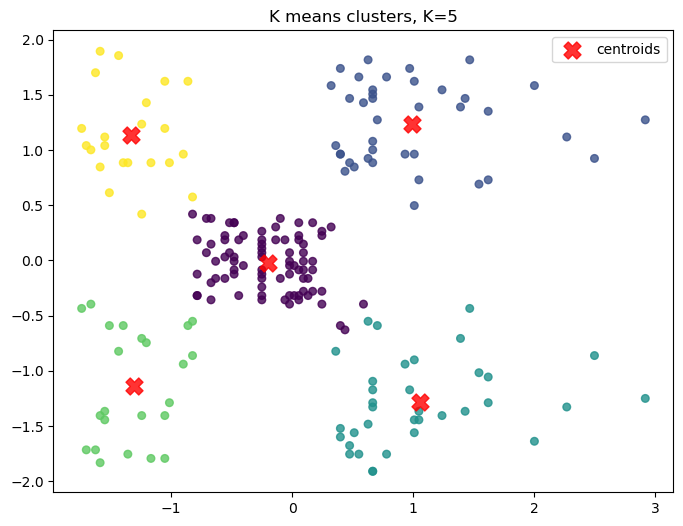

In [24]:
plt.figure(figsize=(8,6))
plt.scatter(Xs_1[:,0],Xs_1[:,1],c=labels_1,cmap='viridis',s = 30, alpha=0.8)
plt.scatter(Kmeans.cluster_centers_[:,0],Kmeans.cluster_centers_[:,1], s = 150, alpha=0.8, c ='red',marker='X',label = 'centroids' )
plt.legend()
plt.title('K means clusters, K=5')
plt.show()

## We Share — Reflection (short, specific)
1) **Which model is better and why?** Reference **Sil (↑), CH (↑), DB (↓)**, **separation ratio (↑)**, **stability ARI (↑)**, and **cluster sizes**.  
- model 1 has higher silhouette, caliski_harabasz and separation ratio scores. At the same time, it has a smaller davies_bouldon, sugggesting that it is the best model
2) **Assumptions & ethics:** Did your chosen model show **non-overlapping, roughly spherical, similarly dense** clusters? If not, what risk could that pose to stakeholders (mis-targeted offers, unfair treatment)?  
- if clusters overlaps or are not spherical, K_means can arbitrarily split or merge groups. Decisions targetting some segments may not reflect their real behaviour, also operational decisions might not be align. In terms of ethics, overlapping clusters can group vulnerable, underepresented group togheter or appart, unabling them from accessing ressources. This make the model unreliable and poor, leading to bad decisions. 
3) **Next step:** If you had to ship this, what monitoring would you add (e.g., re-check metrics quarterly, watch for tiny cluster drift, re-scale after schema changes)?
- I would implement regular check, monitoring how the schema changes, the clusters, and responding to these changes with appropriate preprocessing methods.
> Tip: If metrics conflict (e.g., CH prefers K=6, DB prefers K=4), prefer **parsimonious K** with **clear separation**, **stable labels**, and **business actionability**.
